# WHO COVID-19 Global Trends

This analysis explores global COVID-19 case trends over time and the demographic impact on different age groups.
It highlights key waves, peak periods, and which age groups were most affected, using publicly available WHO data.


## Data Sources

- WHO COVID-19 Global Daily Data  
- WHO COVID-19 Monthly Deaths by Age  

Only the above datasets were used to keep the analysis focused and interpretable.


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

## Load Data


In [2]:
daily_df = pd.read_csv("data/WHO-COVID-19-global-daily-data.csv")
age_df = pd.read_csv("data/WHO-COVID-19-global-monthly-death-by-age-data.csv")

#Preserve Raw data 
daily_raw = daily_df.copy()
age_raw = age_df.copy()

In [3]:
daily_df.info()
daily_df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 516240 entries, 0 to 516239
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Date_reported      516240 non-null  object 
 1   Country_code       514089 non-null  object 
 2   Country            516240 non-null  object 
 3   WHO_region         516240 non-null  object 
 4   New_cases          211809 non-null  float64
 5   Cumulative_cases   516240 non-null  int64  
 6   New_deaths         154656 non-null  float64
 7   Cumulative_deaths  516240 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 31.5+ MB


Index(['Date_reported', 'Country_code', 'Country', 'WHO_region', 'New_cases',
       'Cumulative_cases', 'New_deaths', 'Cumulative_deaths'],
      dtype='object')

In [4]:
age_df.info()
age_df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75032 entries, 0 to 75031
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       75032 non-null  object 
 1   Country_code  75032 non-null  object 
 2   Who_region    74472 non-null  object 
 3   Wb_income     60192 non-null  object 
 4   Year          75032 non-null  int64  
 5   Month         75032 non-null  int64  
 6   Agegroup      75032 non-null  object 
 7   Deaths        18415 non-null  float64
dtypes: float64(1), int64(2), object(5)
memory usage: 4.6+ MB


Index(['Country', 'Country_code', 'Who_region', 'Wb_income', 'Year', 'Month',
       'Agegroup', 'Deaths'],
      dtype='object')

## Data Cleaning and Preparation

Raw datasets were preserved before cleaning to maintain data integrity.
Only essential cleaning steps were applied.


### Cleaning Global Daily Data



In [5]:
daily_df['Date_reported'] = pd.to_datetime(daily_df['Date_reported'])
daily_df["New_cases"] = daily_df["New_cases"].fillna(0)
daily_df['New_deaths'] = daily_df['New_deaths'].fillna(0)
daily_df = daily_df.drop(columns=["Country_code"])
daily_df = daily_df.sort_values("Date_reported")

In [6]:
daily_df.info()
daily_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 516240 entries, 0 to 516239
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Date_reported      516240 non-null  datetime64[ns]
 1   Country            516240 non-null  object        
 2   WHO_region         516240 non-null  object        
 3   New_cases          516240 non-null  float64       
 4   Cumulative_cases   516240 non-null  int64         
 5   New_deaths         516240 non-null  float64       
 6   Cumulative_deaths  516240 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 31.5+ MB


,Date_reported,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-04,Afghanistan,EMR,0.0,0,0.0,0
152,2020-01-04,New Caledonia,WPR,0.0,0,0.0,0
153,2020-01-04,R�union,AFR,0.0,0,0.0,0
154,2020-01-04,Nicaragua,AMR,0.0,0,0.0,0
155,2020-01-04,Luxembourg,EUR,0.0,0,0.0,0


### Cleaning Monthly Deaths by Age Data


In [7]:
age_df = age_df.drop(columns=["Country_code", "Wb_income"])
age_df['Deaths'] = age_df['Deaths'].fillna(0)

age_df['Date'] = pd.to_datetime(age_df["Year"].astype(str) + "-" + age_df["Month"].astype(str) + "-01")

age_df = age_df.sort_values("Date")

In [8]:
age_df.info()
age_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 75032 entries, 75031 to 5334
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Country     75032 non-null  object        
 1   Who_region  74472 non-null  object        
 2   Year        75032 non-null  int64         
 3   Month       75032 non-null  int64         
 4   Agegroup    75032 non-null  object        
 5   Deaths      75032 non-null  float64       
 6   Date        75032 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 4.6+ MB


,Country,Who_region,Year,Month,Agegroup,Deaths,Date
75031,Afghanistan,EMR,2020,1,5_14,0.0,2020-01-01
63577,Chile,AMR,2020,1,65+,0.0,2020-01-01
70286,French Guiana,AMR,2020,1,65+,0.0,2020-01-01
70288,Niger,AFR,2020,1,15_64,0.0,2020-01-01
63585,Turks and Caicos Islands,AMR,2020,1,15_64,0.0,2020-01-01


## Global COVID-19 Trends Over Time


In [9]:
global_daily = (
    daily_df
    .groupby("Date_reported")[["New_cases", "New_deaths"]]
    .sum()
    .reset_index()
)


In [10]:
global_daily.loc[global_daily["New_cases"].idxmax()]

Date_reported    2022-01-30 00:00:00
New_cases                  8401963.0
New_deaths                   17569.0
Name: 757, dtype: object

In [11]:
global_daily.loc[global_daily["New_deaths"].idxmax()]


Date_reported    2023-02-01 00:00:00
New_cases                   176142.0
New_deaths                   57167.0
Name: 1124, dtype: object

### Global Daily COVID-19 Cases


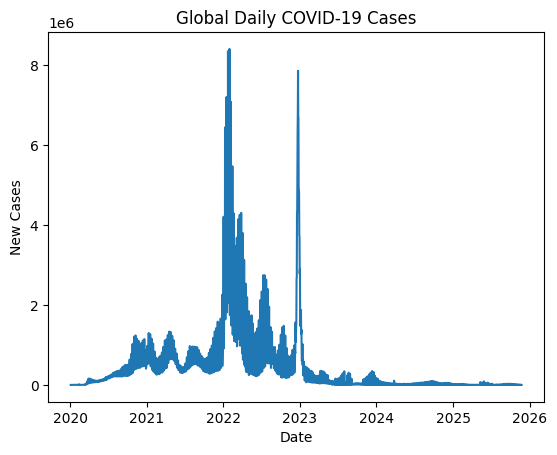

In [12]:
plt.figure()
plt.plot(global_daily["Date_reported"], global_daily["New_cases"])
plt.title("Global Daily COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")

plt.savefig("global_daily_cases.jpeg", dpi=300, bbox_inches="tight")
plt.show()


**Insight:**  
The global daily case count shows multiple waves over time, reflecting periods of rapid transmission followed by declines.


## Demographic Impact: Deaths by Age Group


In [13]:
deaths_by_age = (
    age_df
    .groupby("Agegroup")["Deaths"]
    .sum()
    .reset_index()
    .sort_values("Deaths", ascending=False)
)


In [14]:
deaths_by_age

,Agegroup,Deaths
3,65+,2946904.0
1,15_64,1044925.0
0,0_4,5269.0
2,5_14,3498.0


In [15]:
total_deaths = deaths_by_age["Deaths"].sum()

deaths_by_age["Percentage"] = (
    deaths_by_age["Deaths"] / total_deaths * 100
)



In [16]:
monthly_age_trends = (
    age_df
    .groupby(["Date", "Agegroup"])["Deaths"]
    .sum()
    .reset_index()
)


### Total COVID-19 Deaths by Age Group



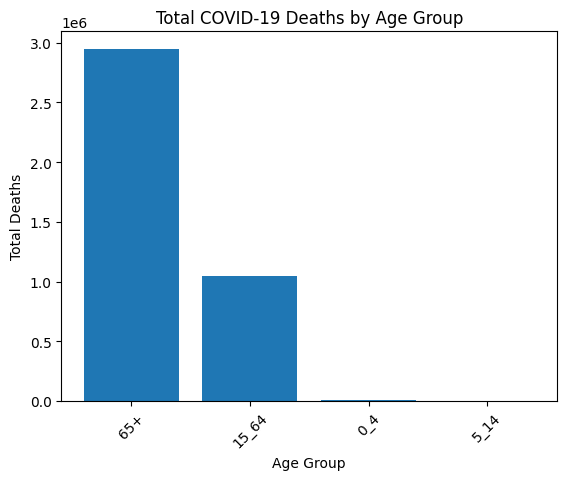

In [17]:
plt.figure()
plt.bar(deaths_by_age["Agegroup"], deaths_by_age["Deaths"])
plt.title("Total COVID-19 Deaths by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Deaths")
plt.xticks(rotation=45)

plt.savefig("deaths_by_age_group.jpeg", dpi=300, bbox_inches="tight")
plt.show()


**Insight:**  
COVID-19 deaths are heavily concentrated in older age groups, with significantly fewer deaths recorded among younger populations.  
This pattern reinforces age as a major risk factor for severe outcomes.


## Key Insights and Limitations

- Global COVID-19 cases exhibited multiple waves over time, showing periods of rapid transmission followed by declines.  
- Older age groups experienced a disproportionately higher number of deaths, highlighting age as a key risk factor.  
- Analysis is based on reported WHO data; underreporting or delays in reporting may affect the results.
